# Yield Curve Analyzer

**Author:** Qemal Ramadani  
**Last Updated:** June 2026  

---

## Overview

This notebook analyzes the US Treasury yield curve using data pulled directly from the Federal Reserve Economic Data (FRED) API. 

The analysis covers:
- Current yield curve shape across key maturities
- Historical curve evolution over time
- Key spread analysis — 2s10s, 2s30s, 3m10y
- Inversion detection and historical context

## Data Source
All yield data is sourced from the [FRED API](https://fred.stlouisfed.org/) maintained by the Federal Reserve Bank of St. Louis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from fredapi import Fred
from datetime import datetime, timedelta

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
#FRED API key & Data Pull
FRED_API_KEY = 'bfcbac5dea58d06023b0bbec9013c8d7'
fred = Fred(api_key=FRED_API_KEY)

#Treasury Yield Data
Treasury_Series = {
    '3-Month': 'DTB3',
    '6-Month': 'DTB6',
    '1-Year': 'DGS1',
    '2-Year': 'DGS2',
    '3-Year': 'DGS3',
    '5-Year': 'DGS5',
    '7-Year': 'DGS7',
    '10-Year': 'DGS10',
    '20-Year': 'DGS20',
    '30-Year': 'DGS30'
}

#Pull data - 10 years of data
end_date = datetime.today()
start_date = end_date - timedelta(days=365*10)
treasury_data = pd.DataFrame()
for maturity, series_id in Treasury_Series.items():
    treasury_data[maturity] = fred.get_series(series_id, start_date, end_date)

#Data Cleaning
treasury_data.dropna(how='all', inplace=True)

treasury_data


,3-Month,6-Month,1-Year,2-Year,3-Year,5-Year,7-Year,10-Year,20-Year,30-Year
2016-06-13,0.27,0.40,0.55,0.73,0.84,1.14,1.42,1.62,2.01,2.43
2016-06-14,0.27,0.40,0.55,0.74,0.85,1.15,1.42,1.62,2.00,2.43
2016-06-15,0.26,0.36,0.52,0.69,0.81,1.10,1.38,1.60,1.99,2.43
2016-06-16,0.27,0.35,0.53,0.70,0.81,1.10,1.37,1.57,1.96,2.39
2016-06-17,0.26,0.36,0.51,0.70,0.83,1.13,1.41,1.62,1.99,2.43
...,...,...,...,...,...,...,...,...,...,...
2026-06-02,3.63,3.65,3.82,4.05,4.09,4.17,4.31,4.46,4.97,4.97
2026-06-03,3.63,3.65,3.84,4.08,4.14,4.21,4.34,4.49,5.00,4.99
2026-06-04,3.63,3.65,3.82,4.05,4.10,4.18,4.32,4.47,4.98,4.97
2026-06-05,3.63,3.68,3.88,4.17,4.22,4.29,4.41,4.55,5.03,5.01


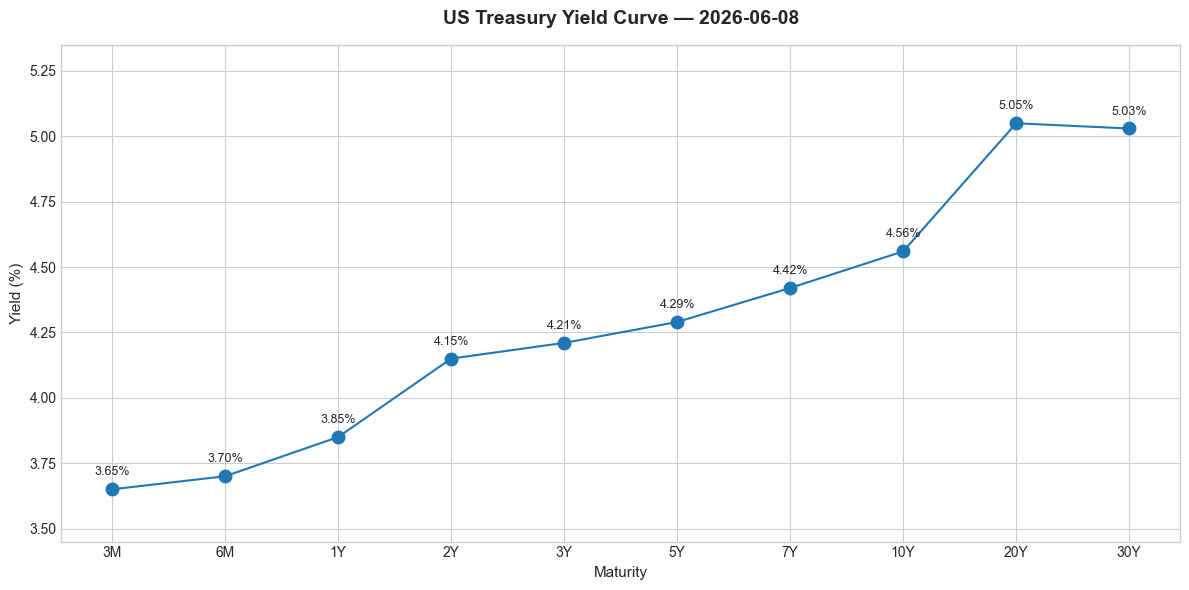

In [27]:
#Current Yield Curve

#Most recent data point
current_yield_curve = treasury_data.iloc[-1]
latest_date = treasury_data.index[-1].strftime('%Y-%m-%d')

#Maturities in years for x-axis
maturities = ['3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']

fig, ax = plt.subplots(figsize = (12, 6))

ax.plot(maturities, current_yield_curve, marker = 'o', markersize = 5, markerfacecolor = 'white', markeredgewidth = 5)

#Labels and title
for x, y in zip(maturities, current_yield_curve.values):
    ax.annotate(f'{y:.2f}%', (x, y), xytext=(0, 10), textcoords='offset points', ha='center', fontsize=9)

ax.set_title(f'US Treasury Yield Curve — {latest_date}', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Maturity', fontsize=11)
ax.set_ylabel('Yield (%)', fontsize=11)
ax.set_ylim(current_yield_curve.min() - 0.2, current_yield_curve.max() + 0.3)

plt.tight_layout()
plt.show()

## Key Spread Analysis

Yield spreads measure the difference in yield between two maturities. They are among the most closely watched indicators in macro, signaling expectations for growth, inflation, and monetary policy.

- **2Y10Y** — 10-Year minus 2-Year. The most widely followed spread.
- **3M10Y** — 10-Year minus 3-Month. The industry preferred recession indicator.
- **2Y30Y** — 30-Year minus 2-Year. Measures the steepness of the long end.

In [43]:
# Key Spreads
spreads = {
    "2Y10Y": treasury_data['10-Year'] - treasury_data['2-Year'],
    "3M10Y": treasury_data['10-Year'] - treasury_data['3-Month'],
    "2Y30Y": treasury_data['30-Year'] - treasury_data['2-Year']
}

spreads_df = pd.DataFrame(spreads, index=[latest_date]).dropna()
for spread, series in spreads_df.items():
    latest_value = series.iloc[-1]
    print(f"{spread} Spread: {latest_value:.2f}% ")

2Y10Y Spread: 0.41% 
3M10Y Spread: 0.91% 
2Y30Y Spread: 0.88% 


In [56]:
#Inversion Detection

for spread_name in spreads_df.columns:
    latest_value = spreads_df[spread_name].iloc[-1]
    if latest_value < 0:
        status = "Inverted"
    elif latest_value < 0.25:
        status = "Flat"
    else:
        status = "Normal"
    
    print(f"{spread_name} Spread: {latest_value:.2f}% — {status}")

2Y10Y Spread: 0.41% — Normal
3M10Y Spread: 0.91% — Normal
2Y30Y Spread: 0.88% — Normal
